# Viability-only MLP: does it denoise as `noise_viab` grows?

Trains a plain `ProfileMLP` (same architecture as the sibling notebooks in this folder) on
**viability only** (`target1`, log enrichment `log((lambda2p+eps)/(lambda0p+eps))`) -- no
`F_sel`/`J_sel` regime is studied here, selectivity is simply not used.

Ground truth is the canonical `F_viab`/`J_viab` (`load_F_viab_aav9_mlp`/`load_J_viab_aav9_mlp`),
i.e. whatever is currently exported to `lib/aav9_F_viab_mlp.npy`/`lib/aav9_J_viab_mlp.npy`. As of
2026-08-13 this is the **regularized** naive-retrieval + L2-credibility-shrinkage GT
(`REG_STRENGTH=5`), not the MLP-probed GT the 2026-08-12 runs of `MLP_for_anticorrelated_weights.ipynb`
used (see project memory `no-mlp-ground-truth-directed-evolution` for why the MLP-probed version was
rejected as GT).

**Question.** As `noise_viab` (the per-cell expression noise `E_{s,j} = exp(noise_viab * Z_{s,j})`
in `Protocol.produce_capsids`) grows, the NGS-measured `target1` gets noisier around the true
noiseless `compute_score(F_viab, J_viab)`. Can the MLP still recover that true score -- i.e. does
`pearson(prediction, true_score)` stay clearly above `pearson(noisy_target1, true_score)` -- or does
the model just mirror whatever noisy label it was handed, with no real denoising benefit?

**Design.** ONE fixed pool of `N=20,000` random sequences (same key/convention as the sibling
notebooks), the SAME train/val/test split reused across every noise level -- only `noise_viab`
changes between runs, so any difference in predictive quality is attributable to noise, not to pool
composition. `F_sel`/`J_sel` are passed to `ProtocolV3` only because its constructor requires
*something*; they don't affect `target1` (viability depends solely on `F_viab`/`J_viab` +
`noise_viab`) and are never read below.


## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth: `F_viab` / `J_viab` (regularized)

Loaded via `load_F_viab_aav9_mlp`/`load_J_viab_aav9_mlp` -- picks up whatever is currently exported
to the `.npy` files, so if those get regenerated again later this cell reflects that automatically.


F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


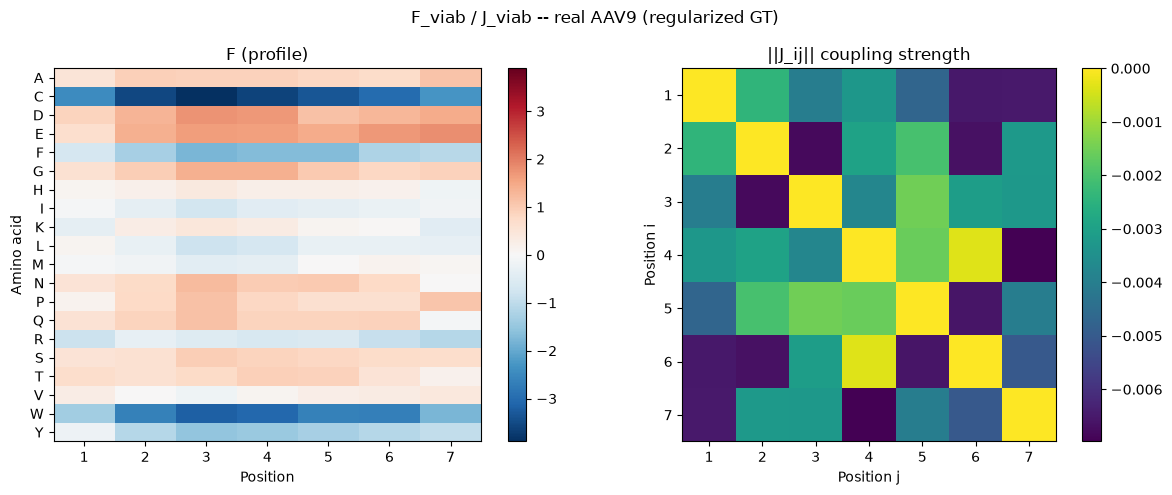

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")
_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9 (regularized GT)")
plt.show()


## 2. Fixed sequence pool, true noiseless score, and the `noise_viab` sweep grid

`compute_score_array` gives the TRUE noiseless score for the fixed pool -- the target the MLP is
trying to recover despite the noisy NGS measurement it's actually trained on. `dataset_filename`/
`build_or_load_dataset` are the same caching helpers as the sibling notebooks (identical recipe),
with a dedicated `label="viabdenoise"` so these CSVs never collide with the selectivity-regime
notebooks' cached files.


In [4]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    ngs_part = "multinomial" if protocol.multinomialNGS else "nbinom"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{ngs_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """(sequence, target1=viability log-enrichment, target2=selectivity log-enrichment)
    dataset for this protocol's parameters -- identical to the sibling notebooks' version."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df


In [5]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Noiseless ground-truth score -- same formula as Protocol.compute_score, decoupled
    from a Protocol instance so it can be applied directly to the fixed sequence pool."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores

true_score_all = np.asarray(compute_score_array(sequences, F_viab, J_viab))

X_all = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences)].reshape(N, -1)

idx_train, idx_test = train_test_split(np.arange(N), test_size=0.5, random_state=0)
X_train_full, X_test = X_all[idx_train], X_all[idx_test]
true_score_test = true_score_all[idx_test]

print(f"sequences: {N:,}   X_train_full: {X_train_full.shape}   X_test: {X_test.shape}")

NOISE_GRID = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.]
print(f"noise_viab sweep: {NOISE_GRID}")


sequences: 20,000   X_train_full: (10000, 140)   X_test: (10000, 140)
noise_viab sweep: [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]


## 3. Model + training loop

Identical `ProfileMLP` (Linear + BatchNorm + Dropout + gelu, twice, then a scalar linear head) and
`train_profile_mlp` (warmup-cosine-decay AdamW, early stopping on val MSE) as the sibling notebooks
-- no bilinear head, on purpose, same reasoning as `cheated_library_MLP.ipynb`.


In [6]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [7]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [8]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


## 4. Sweep: simulate + train one `ProfileMLP` per `noise_viab` level

For each `noise_viab`: run `ProtocolV3.N_loop_DE(1)` on the SAME fixed pool to get a fresh
NGS-measured `target1`, train a fresh `ProfileMLP` on it (same train/val split every time), then
compare on the held-out test fold:
- `r_raw` = `pearson(noisy target1, true_score)` -- how corrupted the raw label already is
- `r_model` = `pearson(prediction, true_score)` -- can the model recover the true score anyway
- `r_fit` = `pearson(prediction, noisy target1)` -- ordinary fit quality vs. its own training label
- top-10% precision, same comparison (raw label vs. prediction) against the true-score ranking


In [9]:
results = []
preds_by_noise   = {}
y_noisy_by_noise = {}
hist_by_noise    = {}
models_by_noise  = {}

for nv in NOISE_GRID:
    print(f"\n=== noise_viab = {nv} ===")
    protocol_nv = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
            dilution_factor=10, sequences=sequences, D=1e9,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_viab, J_sel=J_viab,  # F_sel/J_sel unused dummy
            noise_viab=nv, noise_sel=0.5, T_sel=1, T_viab=1,
            )

    _bio_row, ngs_row = protocol_nv.N_loop_DE(1)[0]
    lambda0p, lambda2p, _lambda3p = (np.asarray(x) for x in ngs_row)
    eps = 1.0  # same pseudocount convention as MLP_for_anticorrelated_weights.ipynb section 1
    log_enr_viab_nv = np.log((lambda2p + eps) / (lambda0p + eps))
    log_enr_sel_nv  = np.zeros_like(log_enr_viab_nv)  # unused placeholder -- only target1 matters here

    dataset_nv = build_or_load_dataset(protocol_nv, sequences, log_enr_viab_nv, log_enr_sel_nv,
                                        label="viabdenoise")
    y_all_nv = dataset_nv["target1"].to_numpy()
    y_train_nv, y_test_nv = y_all_nv[idx_train], y_all_nv[idx_test]

    Xtr, ytr, Xva, yva = split_train_val(X_train_full, y_train_nv, val_frac=0.15, seed=0)
    model_nv, hist_nv = train_profile_mlp(Xtr, ytr, Xva, yva, seed=0, verbose=False)

    pred_test_nv = np.asarray(predict_log_enrichment(model_nv, jnp.asarray(X_test)))

    r_raw   = pearson(y_test_nv, true_score_test)      # raw noisy label vs. true score
    r_model = pearson(pred_test_nv, true_score_test)   # prediction vs. true score
    r_fit   = pearson(pred_test_nv, y_test_nv)          # prediction vs. its own training label

    p_raw_10   = precision_at_k(true_score_test, y_test_nv,    k_frac=0.10)
    p_model_10 = precision_at_k(true_score_test, pred_test_nv, k_frac=0.10)

    print(f"  r(raw noisy target1, true score)  = {r_raw:.3f}")
    print(f"  r(MLP prediction,   true score)   = {r_model:.3f}")
    print(f"  r(MLP prediction,   its own label) = {r_fit:.3f}")
    print(f"  top-10% precision  raw / model     = {p_raw_10:.3f} / {p_model_10:.3f}")

    results.append(dict(noise_viab=nv, r_raw=r_raw, r_model=r_model, r_fit=r_fit,
                         p_raw_10=p_raw_10, p_model_10=p_model_10))
    preds_by_noise[nv]   = pred_test_nv
    y_noisy_by_noise[nv] = y_test_nv
    hist_by_noise[nv]    = hist_nv
    models_by_noise[nv]  = model_nv

results_df = pd.DataFrame(results)
results_df



=== noise_viab = 0.0 ===



Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:   2%|▎         | 1/40 [00:00<00:30,  1.28it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...


Directed evolution rounds: 100%|██████████| 1/1 [00:01<00:00,  1.84s/it]


Directed evolution rounds: 100%|██████████| 1/1 [00:01<00:00,  1.84s/it]

diversity20000_Tsel1_Tviab1_noiseviab8_noisesel05_viabdenoise.csv already exists -- loading from disk


  r(raw noisy target1, true score)  = 0.518
  r(MLP prediction,   true score)   = 0.696
  r(MLP prediction,   its own label) = 0.431
  top-10% precision  raw / model     = 0.135 / 0.224


,noise_viab,r_raw,r_model,r_fit,p_raw_10,p_model_10
0,0.00,0.987004,0.980333,0.968901,0.866,0.834
1,0.10,0.986909,0.980605,0.968904,0.868,0.836
2,0.25,0.986820,0.980610,0.968752,0.870,0.836
3,0.50,0.986384,0.980129,0.968019,0.870,0.832
4,1.00,0.984093,0.979576,0.965198,0.858,0.833
5,2.00,0.964965,0.972479,0.940485,0.785,0.811
6,4.00,0.867747,0.939069,0.820631,0.542,0.697
7,8.00,0.518487,0.695545,0.430952,0.135,0.224


## 5. Does the MLP denoise? Correlation with the TRUE score vs. `noise_viab`

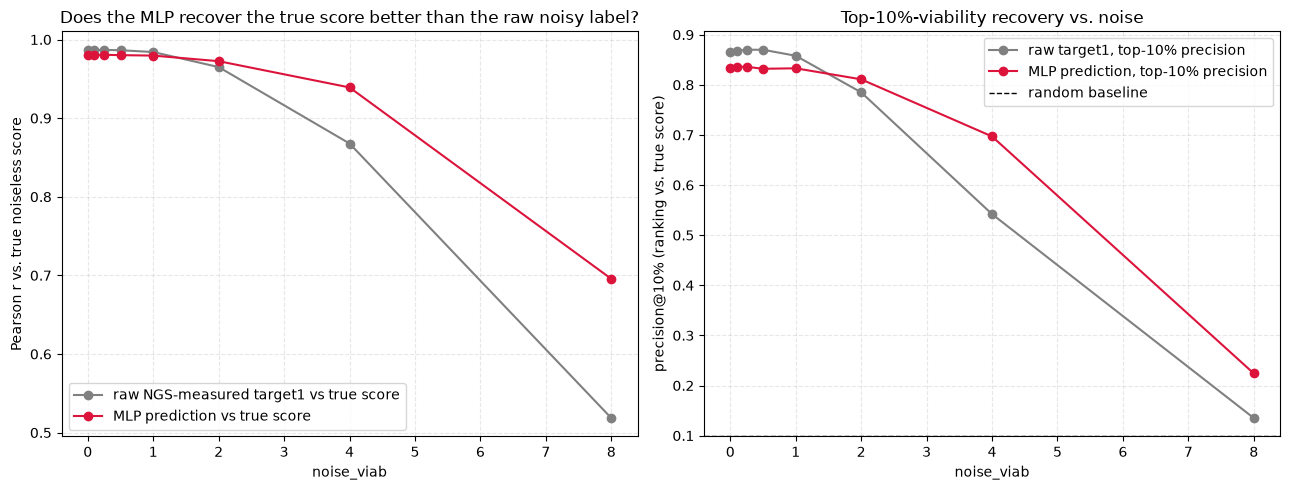

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(results_df["noise_viab"], results_df["r_raw"],   "o-", color="gray",
        label="raw NGS-measured target1 vs true score")
ax.plot(results_df["noise_viab"], results_df["r_model"], "o-", color="crimson",
        label="MLP prediction vs true score")
ax.set_xlabel("noise_viab")
ax.set_ylabel("Pearson r vs. true noiseless score")
ax.set_title("Does the MLP recover the true score better than the raw noisy label?")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(results_df["noise_viab"], results_df["p_raw_10"],   "o-", color="gray",
        label="raw target1, top-10% precision")
ax.plot(results_df["noise_viab"], results_df["p_model_10"], "o-", color="crimson",
        label="MLP prediction, top-10% precision")
ax.axhline(0.10, color="black", lw=1, ls="--", label="random baseline")
ax.set_xlabel("noise_viab")
ax.set_ylabel("precision@10% (ranking vs. true score)")
ax.set_title("Top-10%-viability recovery vs. noise")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


## 6. Scatter: predicted vs. true score, low / mid / high noise

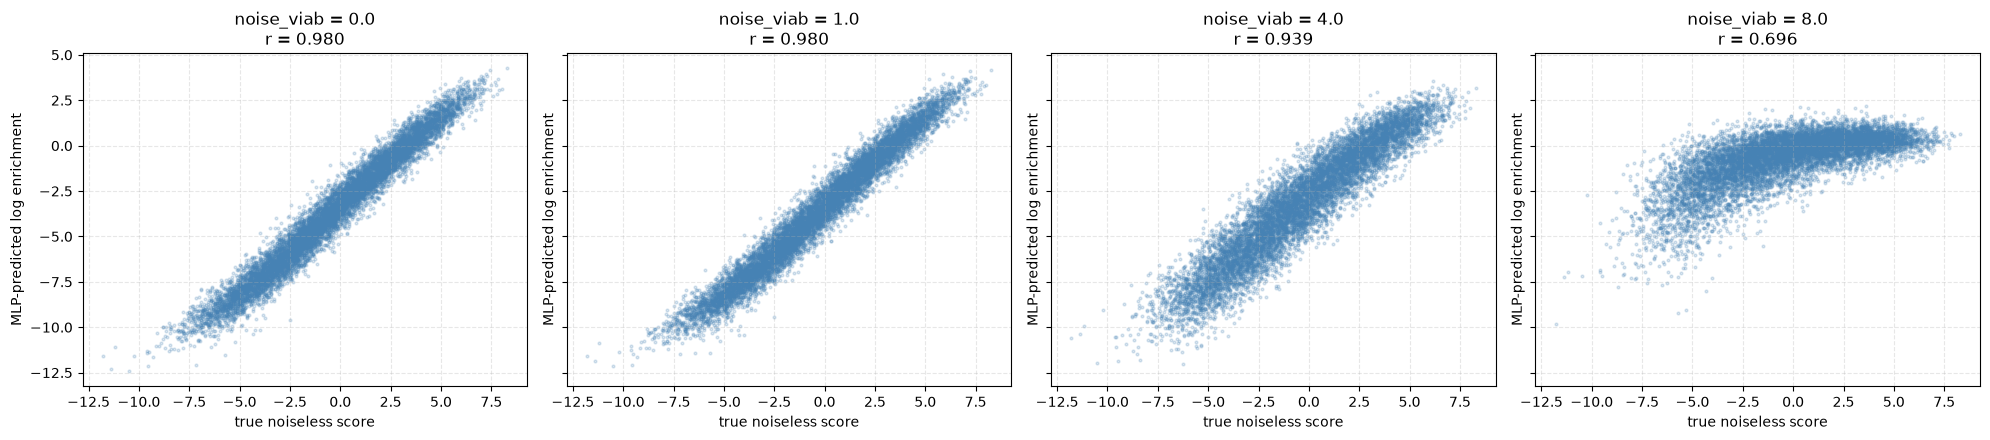

In [11]:
rep_levels = [NOISE_GRID[0], NOISE_GRID[len(NOISE_GRID) // 2], NOISE_GRID[-2], NOISE_GRID[-1]]

fig, axes = plt.subplots(1, len(rep_levels), figsize=(5 * len(rep_levels), 4.5),
                          sharex=True, sharey=True)
for ax, nv in zip(axes, rep_levels):
    r = pearson(preds_by_noise[nv], true_score_test)
    ax.scatter(true_score_test, preds_by_noise[nv], s=4, alpha=0.2, color="steelblue")
    ax.set_xlabel("true noiseless score")
    ax.set_ylabel("MLP-predicted log enrichment")
    ax.set_title(f"noise_viab = {nv}\nr = {r:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 7. Top-k recovery at the hardest noise level

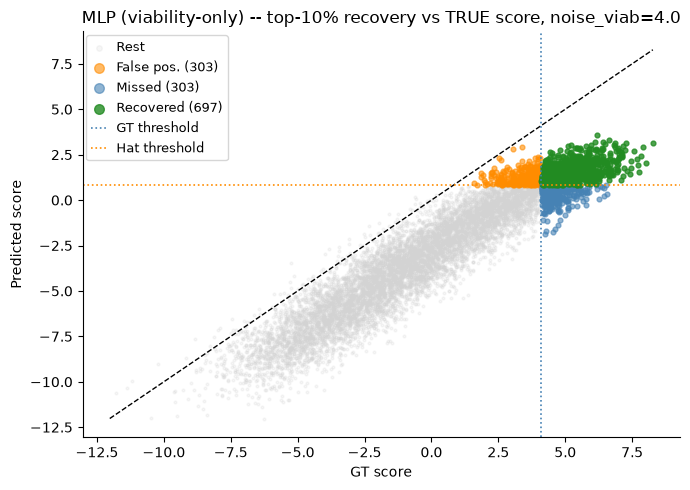

In [ ]:
nv_hardest = NOISE_GRID[-2]
fig = plot_topk_recovery(true_score_test, preds_by_noise[nv_hardest], k_frac=0.10,
                          title=f"MLP (viability-only) -- top-10% recovery vs TRUE score, "
                                f"noise_viab={nv_hardest}")
plt.show()

## 8. Where do the TRUE top-500 GT variants land in the MLP's predicted distribution?

The correlation/precision numbers above are computed on the held-out test fold (ordinary random
variants). But the whole point of a viability model is to recognize the rare, high-value
combinations that pairwise `J` epistasis creates -- the actual global optimum, not just "a decent
variant". This section checks that directly, at every noise level.


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
The <b>GLOBAL/THEORETICAL top-500</b>: an exhaustive brute-force scan (<code>brute_force_top_k</code>)
over all <code>20**7</code> &asymp; 1.28 billion possible sequences against the ground-truth
<code>F_viab</code>/<code>J_viab</code>, keeping <code>K_BEST = 500</code> -- same recipe and same K
as <code>cheated_library_MLP.ipynb</code> section 3 / <code>MLP_bilinear_head_anticorrelated.ipynb</code>
section 5. Checked below to confirm none of these 500 sequences leaked into the fixed 20,000-sequence
pool every noise-level model in this notebook was trained/evaluated on. The gray histogram background
in the plot further down is each noise level's own held-out <b>10,000-sequence test population</b>
(<code>preds_by_noise</code>, from section 4) -- not a separate random sample.
</div>


In [13]:
K_BEST = 500

@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks (so the full A**L x L array of sequences is never
    materialized at once). Identical recipe to the sibling notebooks."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)

# Sanity check: none of the TRUE top-500 leaked into the fixed 20,000-sequence pool every
# noise-level model was trained/evaluated on -- same convention as cheated_library_MLP.ipynb.
pool_set = {tuple(row) for row in np.asarray(sequences)}
overlap = sum(tuple(row) in pool_set for row in best_seqs_viab)
print(f"TRUE top-{K_BEST} GT variants -- overlap with the fixed {N:,}-sequence pool: {overlap}")
assert overlap == 0, "TRUE-best variants leaked into the training/test pool"
print(f"TRUE global-optimum viability score: {best_scores_viab[0]:.2f}")



brute-force scan:   0%|          | 0/64 [00:00<?, ?it/s]


brute-force scan:   2%|▏         | 1/64 [00:01<01:06,  1.05s/it]


brute-force scan:   8%|▊         | 5/64 [00:01<00:10,  5.61it/s]


brute-force scan:  16%|█▌        | 10/64 [00:01<00:04, 11.83it/s]


brute-force scan:  22%|██▏       | 14/64 [00:01<00:03, 15.81it/s]

...


brute-force scan:  92%|█████████▏| 59/64 [00:03<00:00, 18.48it/s]


brute-force scan:  95%|█████████▌| 61/64 [00:03<00:00, 18.28it/s]


brute-force scan:  98%|█████████▊| 63/64 [00:03<00:00, 18.36it/s]


brute-force scan: 100%|██████████| 64/64 [00:03<00:00, 17.68it/s]

TRUE top-500 GT variants -- overlap with the fixed 20,000-sequence pool: 0
TRUE global-optimum viability score: 9.88


In [14]:
pred_best_by_noise = {
    nv: np.asarray(predict_log_enrichment(models_by_noise[nv], jnp.asarray(X_best_viab)))
    for nv in NOISE_GRID
}

for nv in NOISE_GRID:
    pct = [100 * (preds_by_noise[nv] < v).mean() for v in pred_best_by_noise[nv]]
    print(f"noise_viab={nv:>4}: TRUE top-{K_BEST} median percentile in predicted distribution = "
          f"{np.median(pct):5.1f}   (#1 global-optimum variant -> {pct[0]:5.1f}th pct)")


noise_viab= 0.0: TRUE top-500 median percentile in predicted distribution = 100.0   (#1 global-optimum variant -> 100.0th pct)
noise_viab= 0.1: TRUE top-500 median percentile in predicted distribution = 100.0   (#1 global-optimum variant -> 100.0th pct)
noise_viab=0.25: TRUE top-500 median percentile in predicted distribution = 100.0   (#1 global-optimum variant -> 100.0th pct)
noise_viab= 0.5: TRUE top-500 median percentile in predicted distribution = 100.0   (#1 global-optimum variant -> 100.0th pct)
noise_viab= 1.0: TRUE top-500 median percentile in predicted distribution = 100.0   (#1 global-optimum variant -> 100.0th pct)
noise_viab= 2.0: TRUE top-500 median percentile in predicted distribution = 100.0   (#1 global-optimum variant -> 100.0th pct)
noise_viab= 4.0: TRUE top-500 median percentile in predicted distribution =  99.5   (#1 global-optimum variant ->  99.9th pct)
noise_viab= 8.0: TRUE top-500 median percentile in predicted distribution =  76.1   (#1 global-optimum variant 

In [15]:
N_BIG = 2_000_000
key_big = jax.random.key(999)
sequences_big = jax.random.randint(key_big, shape=(N_BIG, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)
X_big = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_big)].reshape(N_BIG, -1)

# Background population for the distribution plots below: a big UNSEEN random sample, scored by
# each model directly (pure inference -- no ProtocolV3/NGS simulation needed, we only need where
# the model's own predicted distribution sits, not a real noisy label to compare against). Much
# closer to the sibling notebooks' 2,000,000-variant `X_big` than the 10,000-sequence held-out
# test fold used elsewhere in this notebook for the r_model/r_raw correlation checks (sections
# 5-7) -- those genuinely need real NGS labels, so they keep using X_test/preds_by_noise as-is.
preds_big_by_noise = {
    nv: np.asarray(predict_log_enrichment(models_by_noise[nv], jnp.asarray(X_big)))
    for nv in NOISE_GRID
}
print(f"X_big: {X_big.shape}")


X_big: (2000000, 140)


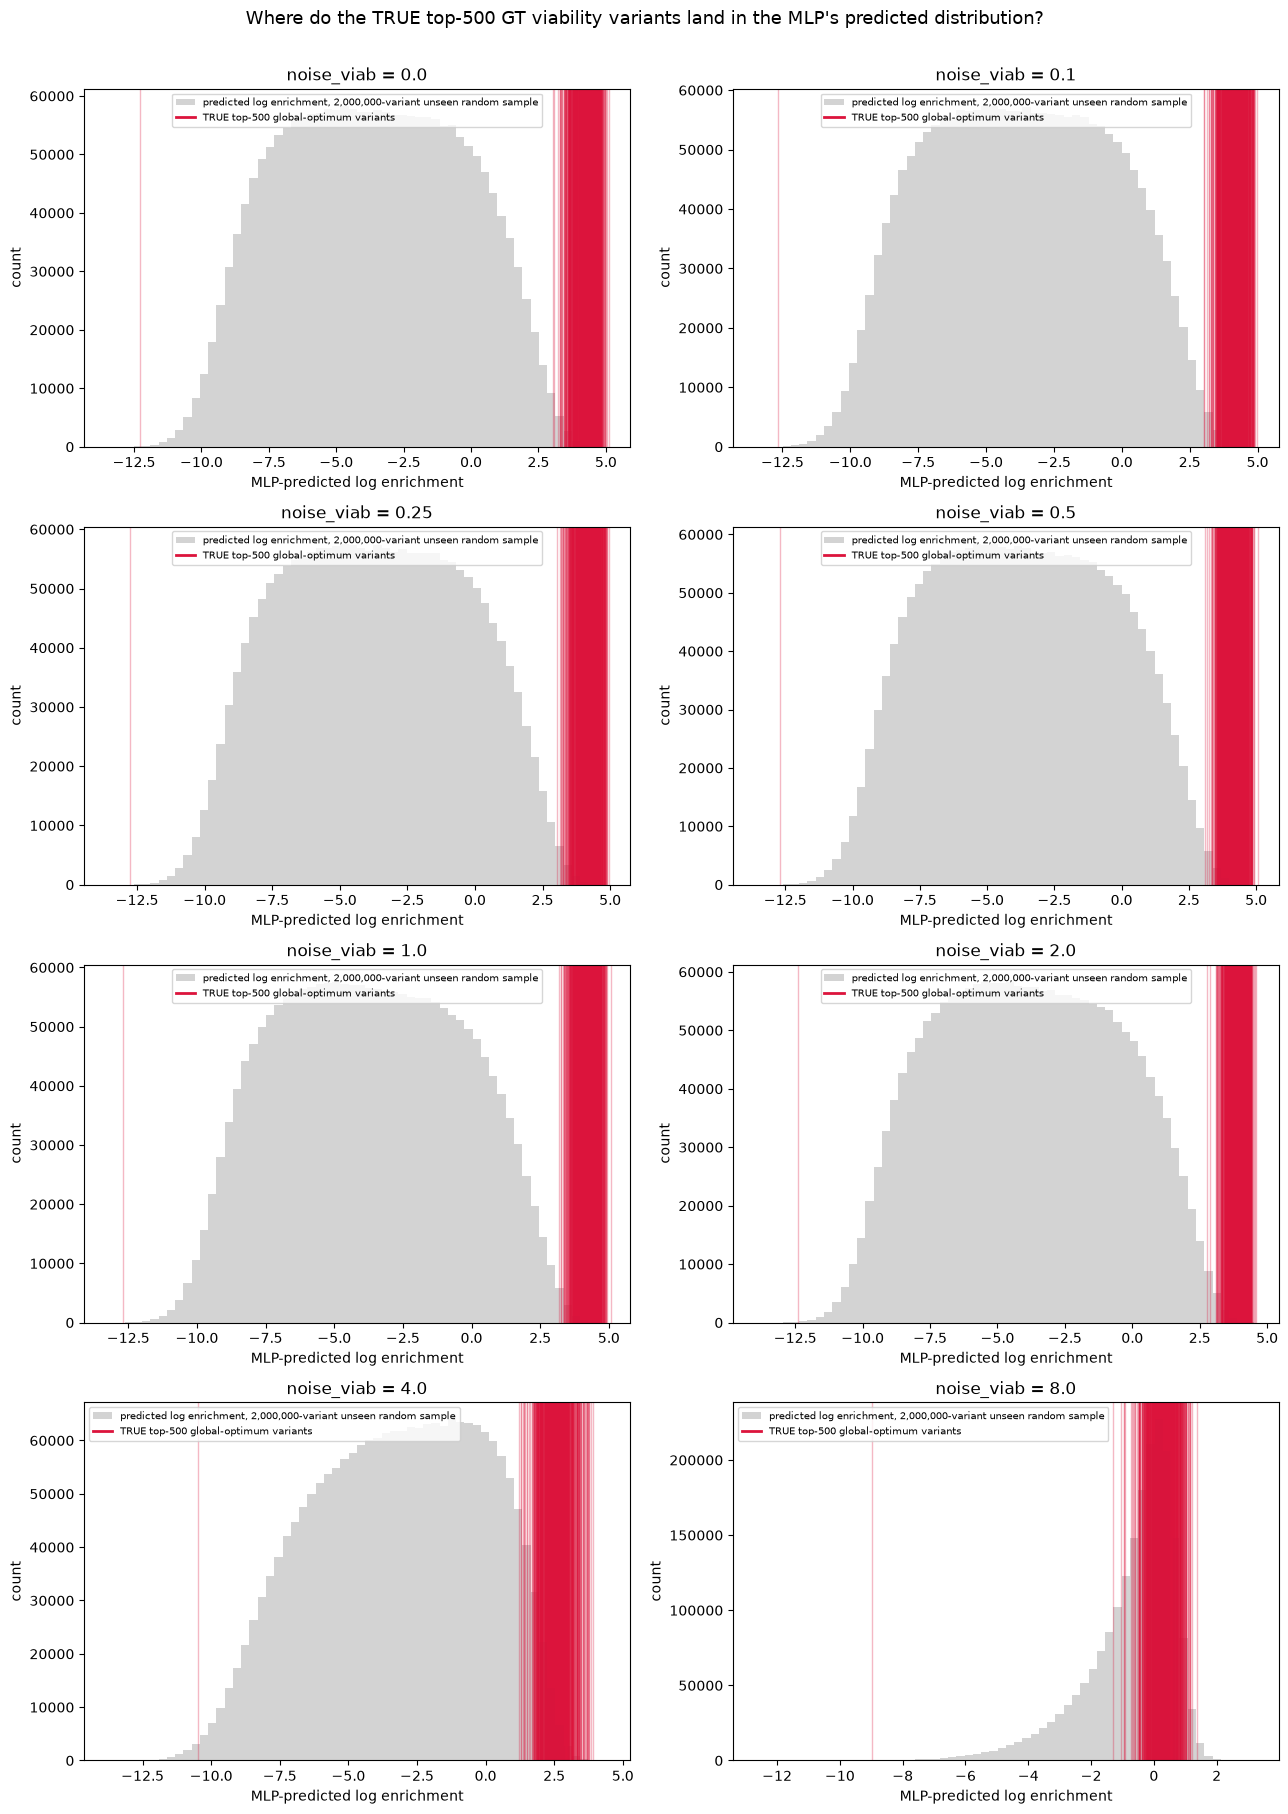

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()
for ax, nv in zip(axes, NOISE_GRID):
    pred_pop  = preds_big_by_noise[nv]
    pred_best = pred_best_by_noise[nv]
    ax.hist(pred_pop, bins=60, color="lightgray",
            label=f"predicted log enrichment, {len(pred_pop):,}-variant unseen random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.3, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("MLP-predicted log enrichment")
    ax.set_ylabel("count")
    ax.set_title(f"noise_viab = {nv}")
    ax.legend(fontsize=7)
for ax in axes[len(NOISE_GRID):]:
    ax.axis("off")
fig.suptitle("Where do the TRUE top-500 GT viability variants land in the MLP's predicted distribution?",
             y=1.005, fontsize=13)
fig.tight_layout()
plt.show()


## 9. Binned calibration: does averaging wash the noise out of the raw label?

Same 20-bin diagnostic as `AAV9_FJ_matrix_top500_check.ipynb` (the naive-`F_GT`/`J_naive`-vs-real-`target`
check), adapted here with the roles filled by this notebook's own variables:
`target` -> `y_noisy_by_noise[nv]` (the raw, noise-corrupted `target1` for the held-out test fold at
that noise level), `gt_score_abs` -> `true_score_test` (this notebook already knows the exact
noiseless score, so no `F_GT`/`J_naive` estimation step is needed -- it's the same fixed
`true_score_test` from section 2 at every noise level, since `X_test`'s sequences never change).

Sequences are ranked and grouped into 20 bins by their own noisy `target1` (exactly like the AAV9
notebook bins by real `target`), then each bin's mean noisy label is plotted against that same bin's
mean TRUE score. If binning recovers something close to `y = x` even where individual points are
scattered, that's direct evidence of the redundancy the MLP is exploiting to denoise (section 5) --
the true signal is there in aggregate, just buried per-point.


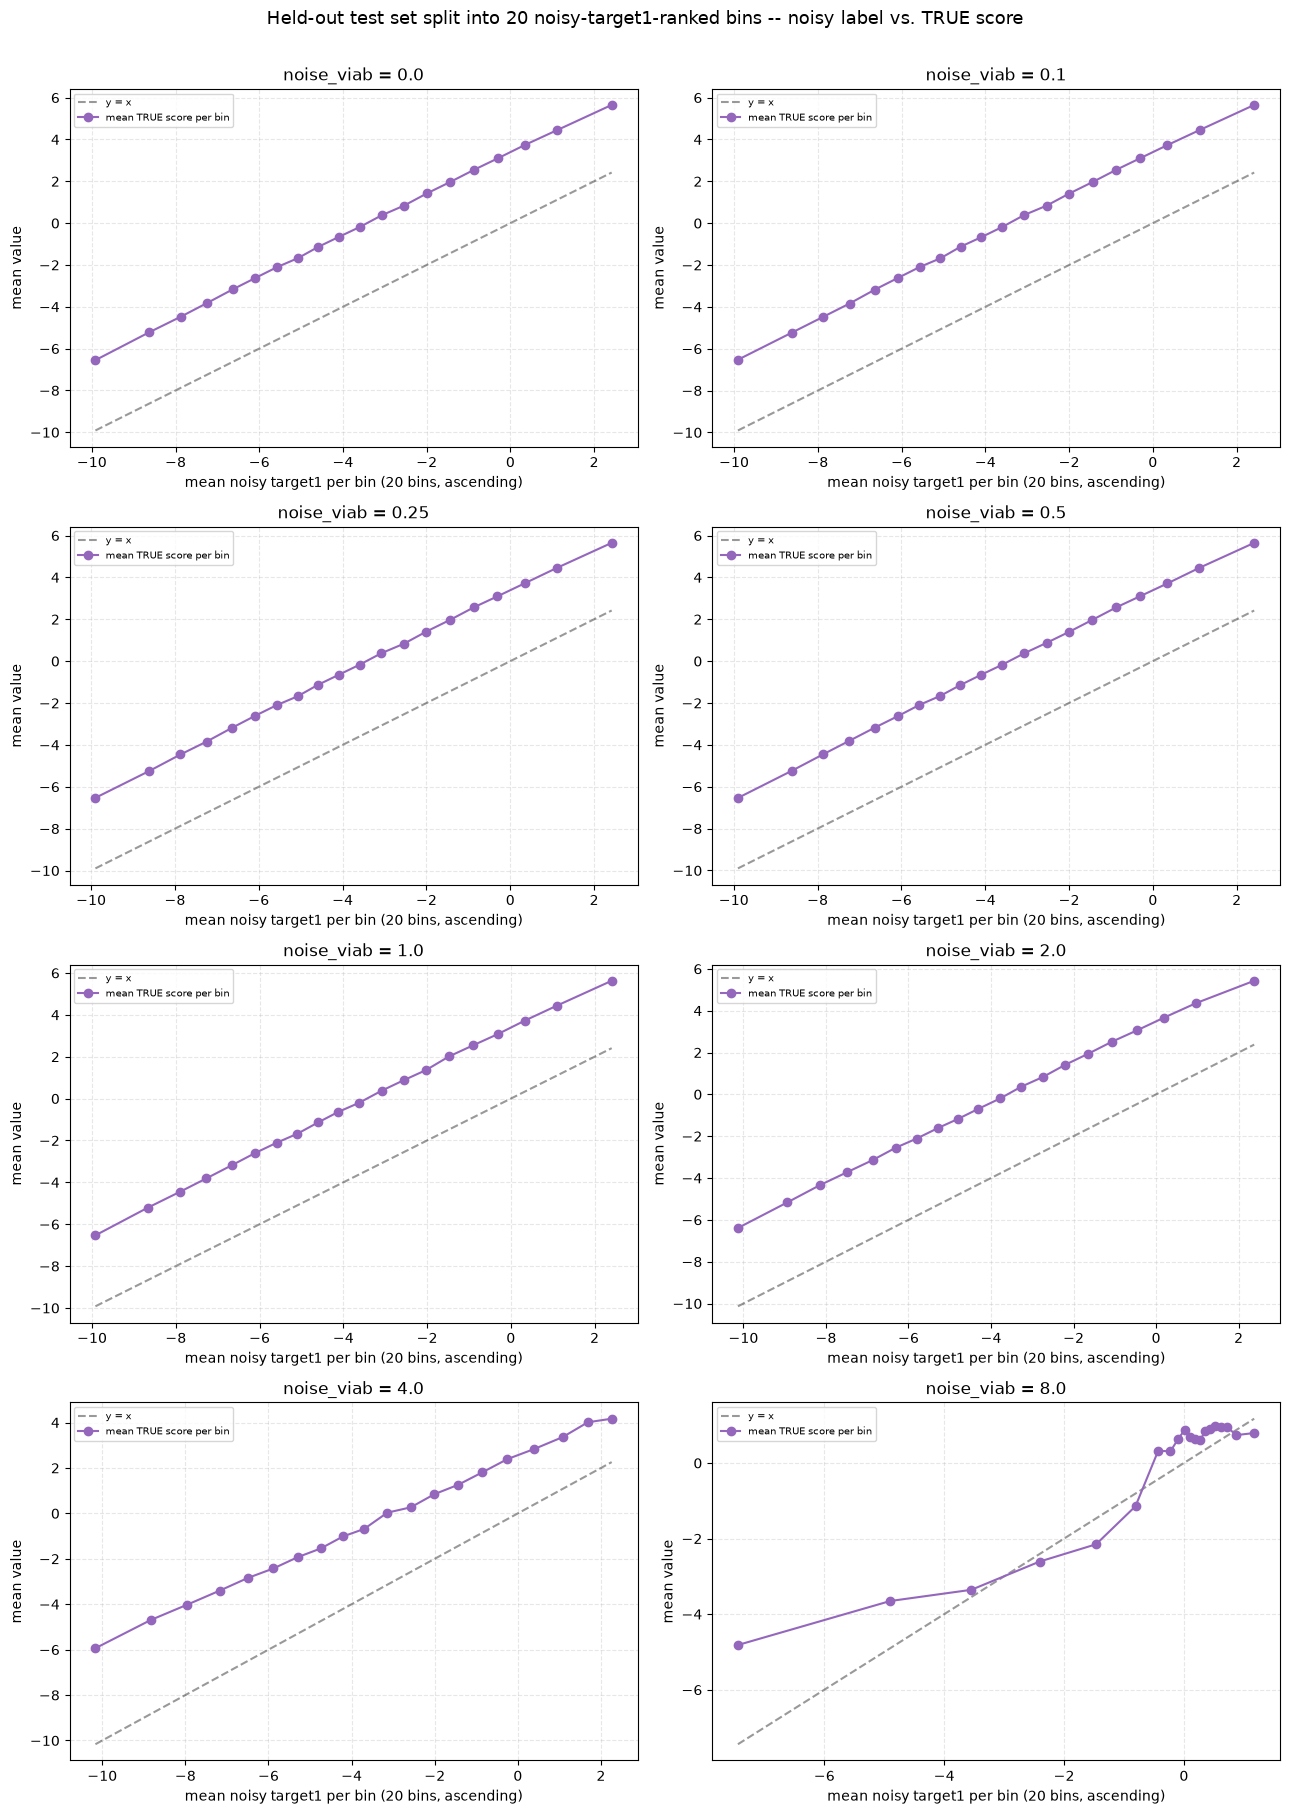

In [17]:
n_bins = 20

fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()
for ax, nv in zip(axes, NOISE_GRID):
    target       = y_noisy_by_noise[nv]
    gt_score_abs = true_score_test

    order      = np.argsort(target)
    bins       = np.array_split(order, n_bins)
    bin_real   = np.array([target[b].mean()       for b in bins])
    bin_score  = np.array([gt_score_abs[b].mean() for b in bins])

    ax.plot(bin_real, bin_real, "k--", alpha=0.4, label="y = x")
    ax.plot(bin_real, bin_score, "o-", color="tab:purple", label="mean TRUE score per bin")
    ax.set_xlabel(f"mean noisy target1 per bin ({n_bins} bins, ascending)")
    ax.set_ylabel("mean value")
    ax.set_title(f"noise_viab = {nv}")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.3)
for ax in axes[len(NOISE_GRID):]:
    ax.axis("off")
fig.suptitle("Held-out test set split into 20 noisy-target1-ranked bins -- noisy label vs. TRUE score",
             y=1.005, fontsize=13)
fig.tight_layout()
plt.show()


## 10. Rank correlation: does the MLP preserve ordering within the extreme tails?

Sections 5-9 look at correlation/calibration against the ordinary test population. This asks a
narrower, more specific question: restricted to the TRUE top-500 (already retrieved in section 8)
and, symmetrically, the TRUE worst-500 -- does the MLP at least get their RELATIVE ordering right,
even if it can't perfectly recover absolute scores? `gt_rank = 1` is the single best (resp. worst)
sequence in that group; `mlp_rank` is where the MLP's own prediction ranks that same sequence
among the same 500-sequence group (not against the wider population).

The worst-500 come from one more exhaustive `20**7` brute-force scan, this time against `-F_viab`/
`-J_viab` (maximizing the negated score == minimizing the real one) -- identical cost to the
top-500 scan in section 8 (a couple of seconds on GPU), and scoring both groups with the
already-trained `models_by_noise` is essentially free.


In [18]:
worst_seqs_viab, _neg_worst_scores = brute_force_top_k(-F_viab, -J_viab, k=K_BEST)
worst_scores_viab = -_neg_worst_scores  # back to the real score scale -- ascending, rank 1 = worst
X_worst_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[worst_seqs_viab].reshape(K_BEST, -1)

overlap_worst = sum(tuple(row) in pool_set for row in worst_seqs_viab)
print(f"TRUE worst-{K_BEST} GT variants -- overlap with the fixed {N:,}-sequence pool: {overlap_worst}")
assert overlap_worst == 0, "TRUE-worst variants leaked into the training/test pool"
print(f"TRUE global-WORST viability score: {worst_scores_viab[0]:.2f}  "
      f"(TRUE global-BEST: {best_scores_viab[0]:.2f})")



brute-force scan:   0%|          | 0/64 [00:00<?, ?it/s]


brute-force scan:   6%|▋         | 4/64 [00:00<00:01, 31.47it/s]


brute-force scan:  14%|█▍        | 9/64 [00:00<00:01, 38.92it/s]


brute-force scan:  22%|██▏       | 14/64 [00:00<00:01, 41.46it/s]


brute-force scan:  30%|██▉       | 19/64 [00:00<00:01, 41.04it/s]

...


brute-force scan:  91%|█████████ | 58/64 [00:02<00:00, 18.20it/s]


brute-force scan:  94%|█████████▍| 60/64 [00:02<00:00, 18.49it/s]


brute-force scan:  97%|█████████▋| 62/64 [00:02<00:00, 18.37it/s]


brute-force scan: 100%|██████████| 64/64 [00:02<00:00, 22.58it/s]

TRUE worst-500 GT variants -- overlap with the fixed 20,000-sequence pool: 0
TRUE global-WORST viability score: -15.23  (TRUE global-BEST: 9.88)


In [19]:
pred_worst_by_noise = {
    nv: np.asarray(predict_log_enrichment(models_by_noise[nv], jnp.asarray(X_worst_viab)))
    for nv in NOISE_GRID
}

def mlp_rank(pred, ascending):
    """1-indexed rank of each prediction WITHIN this same group (not vs. the wider population).
    ascending=False -> rank 1 = highest predicted value (used for the top-K_BEST group);
    ascending=True  -> rank 1 = lowest predicted value (used for the worst-K_BEST group)."""
    return pd.Series(pred).rank(ascending=ascending, method="first").to_numpy().astype(int)

gt_rank = np.arange(1, K_BEST + 1)  # both groups already come out of brute_force_top_k pre-sorted

print(f"{'noise_viab':>10}  {'spearman rho (top-' + str(K_BEST) + ')':>24}  "
      f"{'spearman rho (worst-' + str(K_BEST) + ')':>26}")
for nv in NOISE_GRID:
    rho_best  = spearmanr(gt_rank, mlp_rank(pred_best_by_noise[nv],  ascending=False)).statistic
    rho_worst = spearmanr(gt_rank, mlp_rank(pred_worst_by_noise[nv], ascending=True)).statistic
    print(f"{nv:>10}  {rho_best:>24.3f}  {rho_worst:>26.3f}")


noise_viab    spearman rho (top-500)    spearman rho (worst-500)
       0.0                     0.149                      -0.109
       0.1                     0.191                      -0.109
      0.25                     0.191                      -0.118
       0.5                     0.147                      -0.092
       1.0                     0.161                      -0.053
       2.0                     0.189                       0.003
       4.0                     0.049                      -0.187
       8.0                     0.040                      -0.212


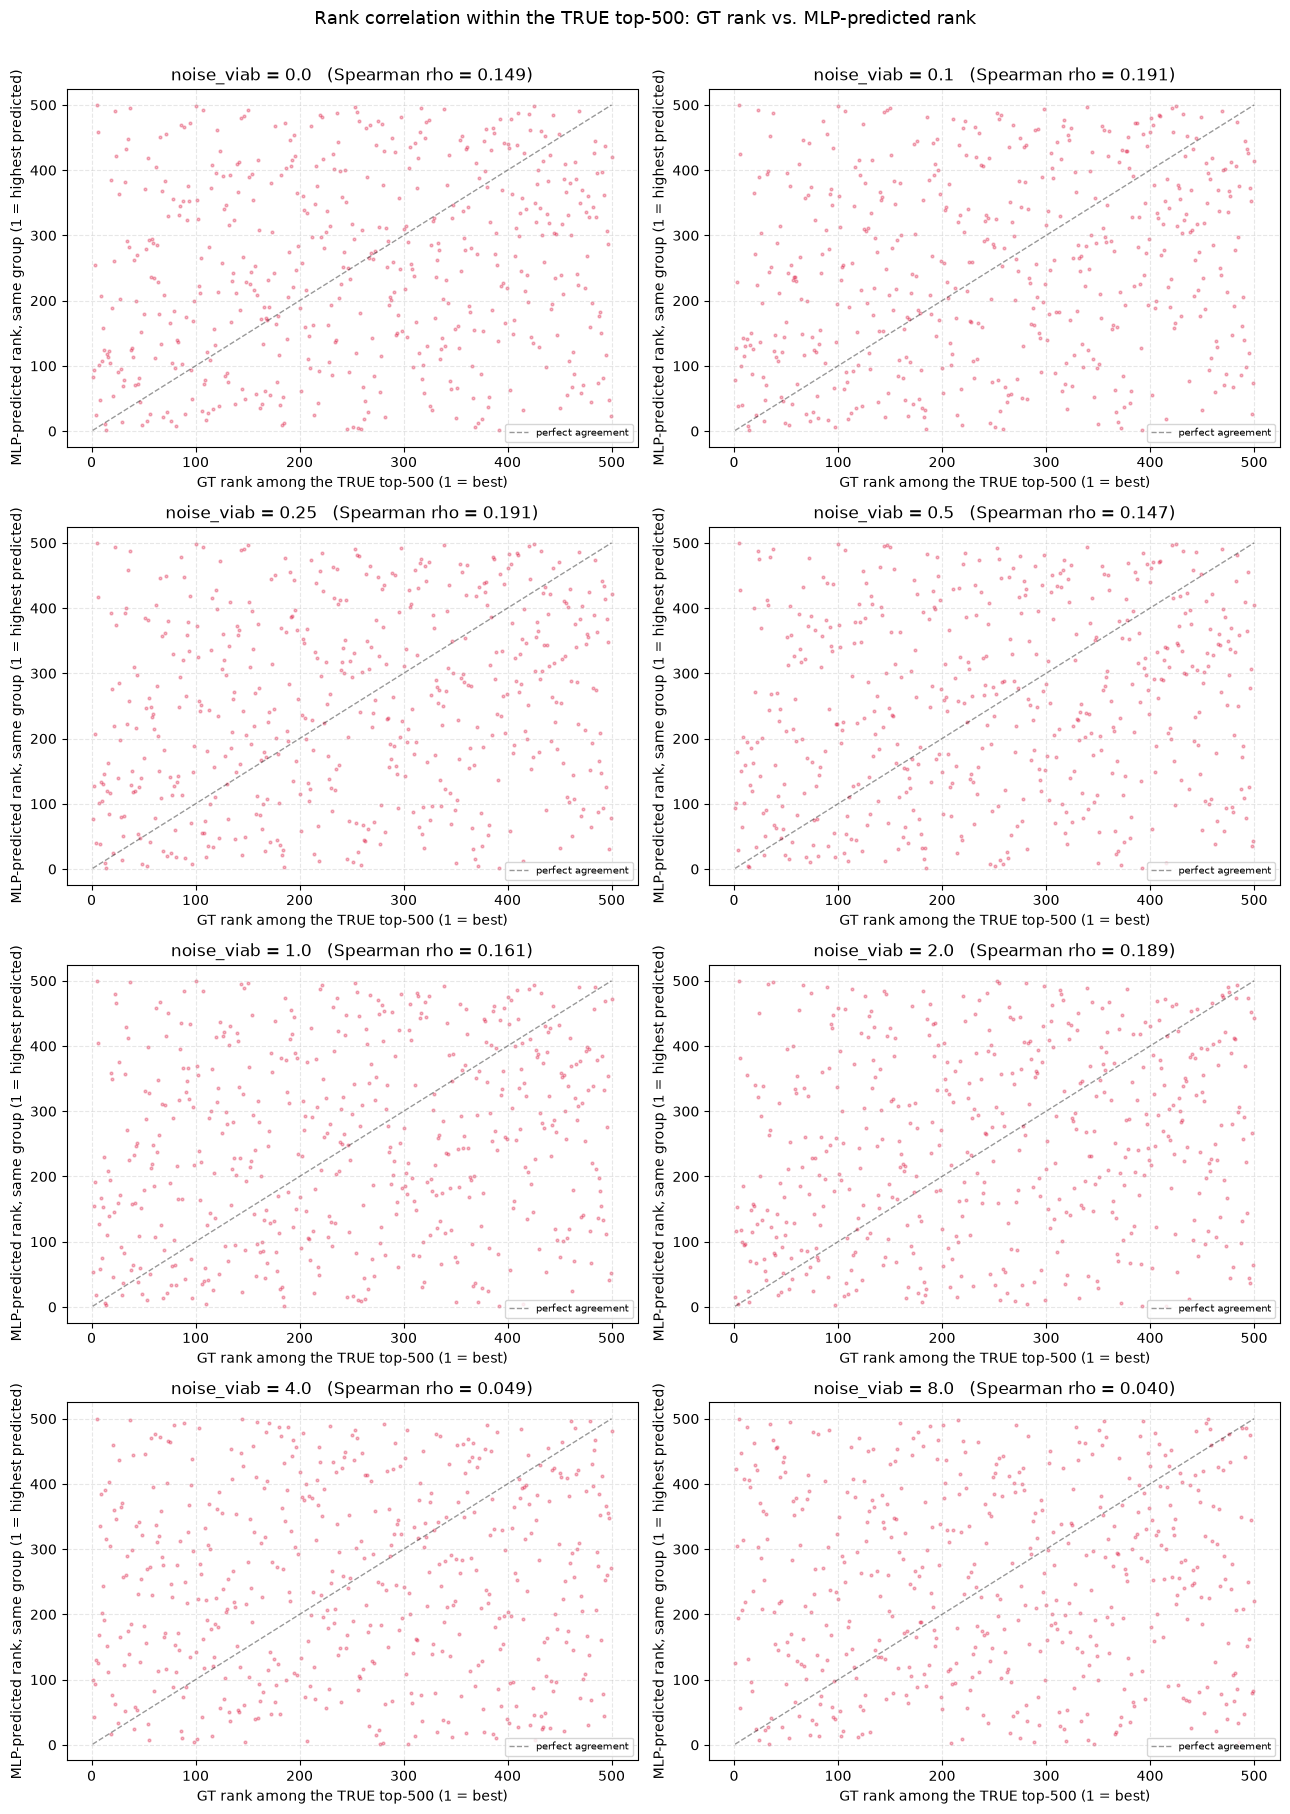

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()
for ax, nv in zip(axes, NOISE_GRID):
    y_rank = mlp_rank(pred_best_by_noise[nv], ascending=False)
    rho = spearmanr(gt_rank, y_rank).statistic
    ax.scatter(gt_rank, y_rank, s=4, alpha=0.3, color="crimson")
    ax.plot([1, K_BEST], [1, K_BEST], "k--", alpha=0.4, lw=1, label="perfect agreement")
    ax.set_xlabel(f"GT rank among the TRUE top-{K_BEST} (1 = best)")
    ax.set_ylabel("MLP-predicted rank, same group (1 = highest predicted)")
    ax.set_title(f"noise_viab = {nv}   (Spearman rho = {rho:.3f})")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.3)
for ax in axes[len(NOISE_GRID):]:
    ax.axis("off")
fig.suptitle(f"Rank correlation within the TRUE top-{K_BEST}: GT rank vs. MLP-predicted rank",
             y=1.005, fontsize=13)
fig.tight_layout()
plt.show()


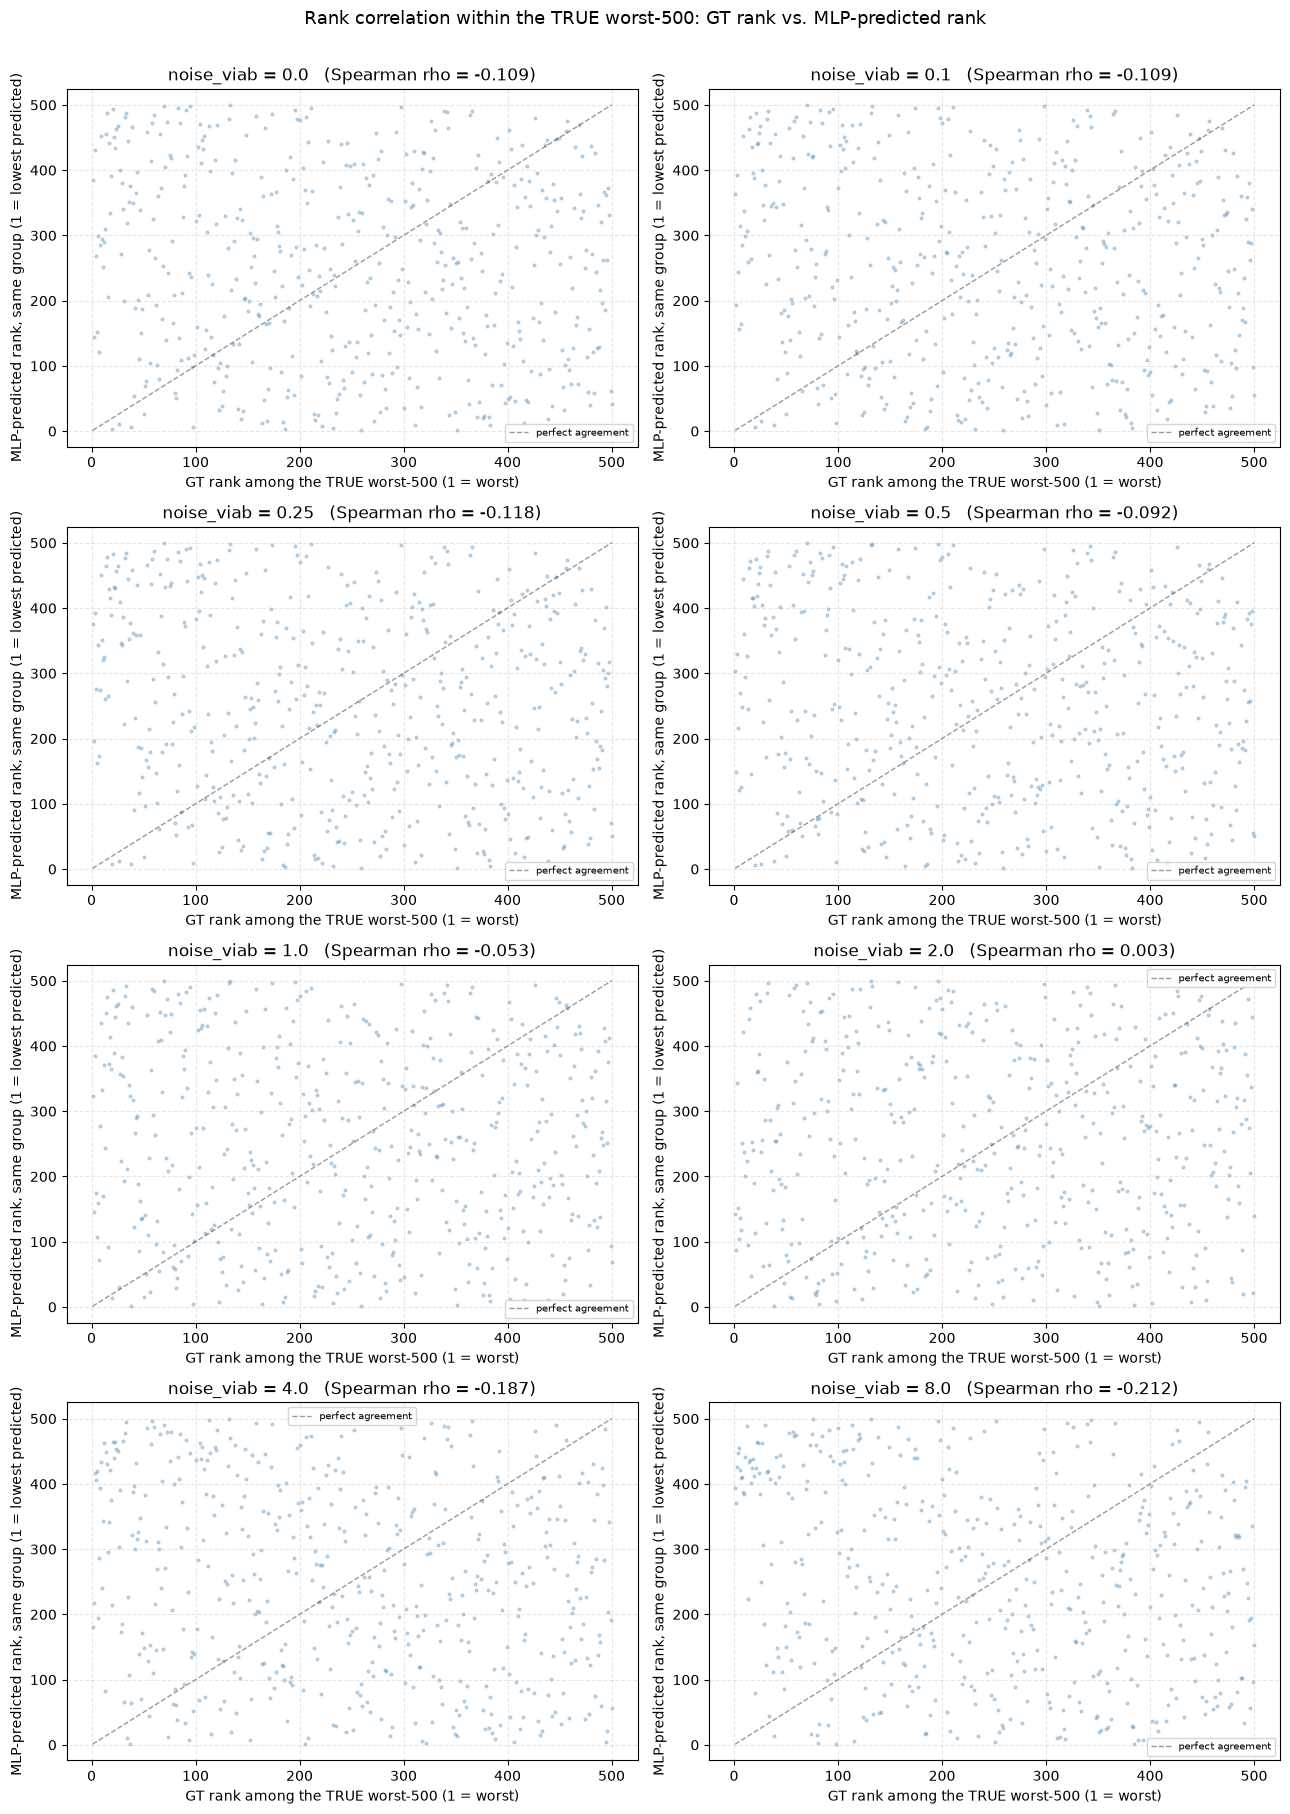

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()
for ax, nv in zip(axes, NOISE_GRID):
    y_rank = mlp_rank(pred_worst_by_noise[nv], ascending=True)
    rho = spearmanr(gt_rank, y_rank).statistic
    ax.scatter(gt_rank, y_rank, s=4, alpha=0.3, color="steelblue")
    ax.plot([1, K_BEST], [1, K_BEST], "k--", alpha=0.4, lw=1, label="perfect agreement")
    ax.set_xlabel(f"GT rank among the TRUE worst-{K_BEST} (1 = worst)")
    ax.set_ylabel("MLP-predicted rank, same group (1 = lowest predicted)")
    ax.set_title(f"noise_viab = {nv}   (Spearman rho = {rho:.3f})")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.3)
for ax in axes[len(NOISE_GRID):]:
    ax.axis("off")
fig.suptitle(f"Rank correlation within the TRUE worst-{K_BEST}: GT rank vs. MLP-predicted rank",
             y=1.005, fontsize=13)
fig.tight_layout()
plt.show()


## 11. Training on the extremes: does it fix the within-tail ranking?

Section 10 found that the baseline MLP separates the TRUE top-500 (and worst-500) from the bulk of
the population very well (section 8: 100th percentile up to `noise_viab=2.0`), but barely orders
them AMONG THEMSELVES (Spearman rho ~0.15 for the top-500, ~0 for the worst-500) -- it knows "this
group is exceptional" but not "which one in the group is the most exceptional". The natural
question: does training ON these extremes fix that?

Two training variants, both reusing the already brute-forced `best_seqs_viab`/`worst_seqs_viab`
(sections 8/10) and the REALISTIC (NGS-simulated, not noiseless-cheat) injection convention from
`cheated_library_MLP.ipynb` section 5:

- **Model A ("augmented")** -- the SAME fixed 20,000-sequence pool as every other model in this
  notebook, plus the K_BEST best + K_BEST worst injected into the training fold only (val/test stay
  exactly as before, so it's directly comparable to the baseline `models_by_noise`).
- **Model B ("designed library")** -- a brand-new 20,000-sequence pool where the K_BEST best REPLACE
  part of the random pool outright (K_BEST best + `N - K_BEST` fresh random -- what a real
  designed-library experiment would look like), no worst-K_BEST included. Held-out test is carved
  only from its own random component (the K_BEST best always stay in train).

**Scope**: 3 representative noise levels (`0.5`, `2.0`, `4.0` -- low/mid/high, same convention as
section 6) instead of the full 8-level sweep, to keep this tractable. The new "recovery rate" metric
below needs `brute_force_top_k_mlp`: an exhaustive scan of the ENTIRE `20**7` space through each
trained model (not the F/J-only formula) -- ~20x more chunks than section 8's brute force, so
noticeably slower. This section runs 9 such scans (baseline + A + B, x 3 noise levels); running the
whole thing in the background as usual, will report back once it's done.

> **`K_BEST = 10000` here** (vs. `500` in sections 8-10, unaffected by this change -- see cell
> below). At this size Model A's injected extremes (`2 * K_BEST = 20,000` sequences) heavily
> outnumber its ~8,500-example original training fold, and Model B's pool becomes a 50/50 split
> (`K_BEST` best + `K_BEST` random) instead of a small ~2.5% "spike" -- a much more aggressive
> composition than the original 500-based design. Also, `brute_force_top_k_mlp`'s per-chunk
> `top_k` now operates over much larger candidate arrays (up to `2*K_BEST=20,000` elements instead
> of `1,000`), so the 9 exhaustive scans in this section will take noticeably longer than before.


In [22]:
NOISE_LEVELS_FOCUS = [0.5, 2.0, 4.0]
assert set(NOISE_LEVELS_FOCUS).issubset(set(NOISE_GRID))

K_BEST = 10000  # overrides section 8's K_BEST=500 for this section only -- sections 8-10 above
                # already executed with K_BEST=500 and are unaffected by this; everything below
                # (best/worst-K_BEST sets, gt_rank) is recomputed fresh at the new size.

best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
X_best_viab  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
overlap_best = sum(tuple(row) in pool_set for row in best_seqs_viab)
assert overlap_best == 0, "TRUE-best variants leaked into the training/test pool"

worst_seqs_viab, _neg_worst_scores = brute_force_top_k(-F_viab, -J_viab, k=K_BEST)
worst_scores_viab = -_neg_worst_scores
X_worst_viab  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[worst_seqs_viab].reshape(K_BEST, -1)
overlap_worst = sum(tuple(row) in pool_set for row in worst_seqs_viab)
assert overlap_worst == 0, "TRUE-worst variants leaked into the training/test pool"

gt_rank = np.arange(1, K_BEST + 1)  # re-derive at the new size -- section 10's gt_rank was (500,)

extreme_seqs = np.concatenate([best_seqs_viab, worst_seqs_viab], axis=0)
print(f"extreme_seqs: {extreme_seqs.shape}  ({K_BEST} TRUE-best + {K_BEST} TRUE-worst)")



brute-force scan:   0%|          | 0/64 [00:00<?, ?it/s]


brute-force scan:   2%|▏         | 1/64 [00:00<00:22,  2.84it/s]


brute-force scan:  11%|█         | 7/64 [00:00<00:03, 18.31it/s]


brute-force scan:  17%|█▋        | 11/64 [00:00<00:02, 24.31it/s]


brute-force scan:  23%|██▎       | 15/64 [00:00<00:02, 23.35it/s]

...


brute-force scan:  84%|████████▍ | 54/64 [00:01<00:00, 43.74it/s]


brute-force scan:  92%|█████████▏| 59/64 [00:01<00:00, 44.12it/s]


brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 43.95it/s]


brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 40.62it/s]

extreme_seqs: (20000, 7)  (10000 TRUE-best + 10000 TRUE-worst)


In [23]:
# Section 8's `pred_best_by_noise` was computed against the OLD K_BEST=500 `X_best_viab` --
# stale now that section 11 redefines X_best_viab at K_BEST=10000. Recompute the baseline
# model's predictions on the NEW X_best_viab, scoped to this section only (kept as a separate
# dict so section 8/10's own results above are left untouched).
pred_best_baseline = {
    nv: np.asarray(predict_log_enrichment(models_by_noise[nv], jnp.asarray(X_best_viab)))
    for nv in NOISE_LEVELS_FOCUS
}


In [24]:
def realistic_labels_for_extremes(nv):
    """Runs the fixed 20,000-sequence pool + the K_BEST best + K_BEST worst TOGETHER through a fresh
    ProtocolV3 simulation at this noise_viab, so the injected extremes get a REALISTIC NGS-measured
    log enrichment -- identical recipe to cheated_library_MLP.ipynb section 5. Returns realistic
    labels for JUST the injected extremes (K_BEST best first, then K_BEST worst)."""
    seq_aug = jnp.concatenate([sequences, jnp.asarray(extreme_seqs)], axis=0)
    protocol_aug = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
            dilution_factor=10, sequences=seq_aug, D=1e9,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_viab, J_sel=J_viab,
            noise_viab=nv, noise_sel=0.5, T_sel=1, T_viab=1,
            )
    _bio_row, ngs_row = protocol_aug.N_loop_DE(1)[0]
    lambda0p, lambda2p, _lambda3p = (np.asarray(x) for x in ngs_row)
    eps = 1.0
    log_enr_viab_aug = np.log((lambda2p + eps) / (lambda0p + eps))
    n_random = sequences.shape[0]
    return log_enr_viab_aug[n_random:]  # (2*K_BEST,) -- K_BEST best labels, then K_BEST worst labels


In [25]:
key_designed = jax.random.key(123)
n_random_designed = N - K_BEST
sequences_designed_random = jax.random.randint(key_designed, shape=(n_random_designed, NUM_POSITIONS),
                                                minval=0, maxval=NUM_AMINO_ACIDS)
sequences_designed = jnp.concatenate([jnp.asarray(best_seqs_viab), sequences_designed_random], axis=0)

rand_positions = np.arange(K_BEST, N)  # rows K_BEST..N-1 are the "rest randoms"
idx_train_rand, idx_test_designed = train_test_split(rand_positions, test_size=0.5, random_state=0)
idx_train_designed_full = np.concatenate([np.arange(K_BEST), idx_train_rand])  # K_BEST best always train

X_designed_all         = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_designed)].reshape(N, -1)
X_train_designed_full  = X_designed_all[idx_train_designed_full]
X_test_designed         = X_designed_all[idx_test_designed]

print(f"designed library: {K_BEST} TRUE-best + {n_random_designed:,} fresh random = {N:,} total")
print(f"train (incl. the {K_BEST} best): {len(idx_train_designed_full):,}   "
      f"test (random only): {len(idx_test_designed):,}")


designed library: 10000 TRUE-best + 10,000 fresh random = 20,000 total
train (incl. the 10000 best): 15,000   test (random only): 5,000


In [26]:
@jax.jit
def _onehot_chunk(idx, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    seq_oh = jnp.eye(A, dtype=jnp.float32)[seq].reshape(seq.shape[0], -1)
    return seq, seq_oh


def brute_force_top_k_mlp(model, k=50, chunk_size=1_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Same exhaustive 20**7 scan as brute_force_top_k, but scores every sequence with the TRAINED
    ProfileMLP instead of the ground-truth F/J -- finds the model's own favorite sequences across
    the ENTIRE space, not just a random sample. Identical recipe to
    MLP_for_anticorrelated_weights.ipynb."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="MLP brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, seq_oh_chunk = _onehot_chunk(idx)
        scores_chunk = predict_log_enrichment(model, seq_oh_chunk)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


def recovery_rate(model):
    """Fraction of the model's OWN top-K_BEST (found by exhaustively scanning the model over the
    entire 20**7 space) that coincide with the TRUE top-K_BEST (best_seqs_viab, from the GT)."""
    mlp_top_seqs, _ = brute_force_top_k_mlp(model, k=K_BEST)
    gt_set  = {tuple(row) for row in best_seqs_viab}
    overlap = sum(tuple(row) in gt_set for row in mlp_top_seqs)
    return overlap / K_BEST


In [27]:
models_A_by_noise, preds_A_by_noise, pred_best_A_by_noise = {}, {}, {}
models_B_by_noise, preds_B_by_noise, pred_best_B_by_noise = {}, {}, {}
recovery = []

for nv in NOISE_LEVELS_FOCUS:
    print(f"\n=== noise_viab = {nv} ===")

    # --- reload this noise level's already-cached random-pool labels (built + saved in section 4) ---
    protocol_nv = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
            dilution_factor=10, sequences=sequences, D=1e9,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_viab, J_sel=J_viab,
            noise_viab=nv, noise_sel=0.5, T_sel=1, T_viab=1,
            )
    csv_path = dataset_filename(protocol_nv, "viabdenoise")
    assert os.path.exists(csv_path), f"expected section 4 to have already cached {csv_path}"
    dataset_nv = pd.read_csv(csv_path)
    y_all_nv   = dataset_nv["target1"].to_numpy()
    y_train_nv, y_test_nv = y_all_nv[idx_train], y_all_nv[idx_test]
    assert np.allclose(y_test_nv, y_noisy_by_noise[nv]), "cached test labels don't match section 4"

    # --- Model A: augmented -- original train fold + 2*K_BEST injected extremes, realistic labels ---
    y_extremes = realistic_labels_for_extremes(nv)
    Xtr_nv, ytr_nv, Xva_nv, yva_nv = split_train_val(X_train_full, y_train_nv, val_frac=0.15, seed=0)
    Xtr_A = np.concatenate([Xtr_nv, X_best_viab, X_worst_viab], axis=0)
    ytr_A = np.concatenate([ytr_nv, y_extremes], axis=0)
    model_A, _ = train_profile_mlp(Xtr_A, ytr_A, Xva_nv, yva_nv, seed=0, verbose=False)

    models_A_by_noise[nv]     = model_A
    preds_A_by_noise[nv]      = np.asarray(predict_log_enrichment(model_A, jnp.asarray(X_test)))
    pred_best_A_by_noise[nv]  = np.asarray(predict_log_enrichment(model_A, jnp.asarray(X_best_viab)))

    # --- Model B: designed library -- K_BEST best + N-K_BEST fresh random, single simulation ---
    protocol_designed = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
            dilution_factor=10, sequences=sequences_designed, D=1e9,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_viab, J_sel=J_viab,
            noise_viab=nv, noise_sel=0.5, T_sel=1, T_viab=1,
            )
    _bio_row, ngs_row = protocol_designed.N_loop_DE(1)[0]
    lambda0p_d, lambda2p_d, _lambda3p_d = (np.asarray(x) for x in ngs_row)
    eps = 1.0
    y_all_designed         = np.log((lambda2p_d + eps) / (lambda0p_d + eps))
    y_train_designed_full  = y_all_designed[idx_train_designed_full]
    y_test_designed         = y_all_designed[idx_test_designed]

    Xtr_B, ytr_B, Xva_B, yva_B = split_train_val(X_train_designed_full, y_train_designed_full,
                                                  val_frac=0.15, seed=0)
    model_B, _ = train_profile_mlp(Xtr_B, ytr_B, Xva_B, yva_B, seed=0, verbose=False)

    models_B_by_noise[nv]    = model_B
    preds_B_by_noise[nv]     = np.asarray(predict_log_enrichment(model_B, jnp.asarray(X_test_designed)))
    pred_best_B_by_noise[nv] = np.asarray(predict_log_enrichment(model_B, jnp.asarray(X_best_viab)))

    # --- recovery rate: how many of each model's OWN top-K_BEST (exhaustive scan) are the TRUE top-K_BEST ---
    rec_baseline = recovery_rate(models_by_noise[nv])
    rec_A        = recovery_rate(model_A)
    rec_B        = recovery_rate(model_B)
    print(f"  recovery rate (baseline / augmented A / designed B): "
          f"{rec_baseline:.1%} / {rec_A:.1%} / {rec_B:.1%}")
    recovery.append(dict(noise_viab=nv, baseline=rec_baseline, augmented_A=rec_A, designed_B=rec_B))

recovery_df = pd.DataFrame(recovery)
recovery_df



=== noise_viab = 0.5 ===



Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:   2%|▎         | 1/40 [00:00<00:31,  1.25it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...


MLP brute-force scan: 100%|█████████▉| 1275/1280 [00:31<00:00, 23.49it/s]


MLP brute-force scan: 100%|█████████▉| 1278/1280 [00:31<00:00, 22.92it/s]


MLP brute-force scan: 100%|██████████| 1280/1280 [00:31<00:00, 40.41it/s]

  recovery rate (baseline / augmented A / designed B): 0.2% / 0.0% / 0.0%


,noise_viab,baseline,augmented_A,designed_B
0,0.5,0.0902,0.0,0.3242
1,2.0,0.0584,0.0,0.1097
2,4.0,0.0022,0.0,0.0000


In [28]:
# Same big unseen background as section 8, now for models A/B too.
preds_big_A_by_noise = {
    nv: np.asarray(predict_log_enrichment(models_A_by_noise[nv], jnp.asarray(X_big)))
    for nv in NOISE_LEVELS_FOCUS
}
preds_big_B_by_noise = {
    nv: np.asarray(predict_log_enrichment(models_B_by_noise[nv], jnp.asarray(X_big)))
    for nv in NOISE_LEVELS_FOCUS
}


In [29]:
RANK_TOL = 100

def rank_agreement(pred, ascending, tol=RANK_TOL):
    """Count and fraction of the group where the MLP-predicted rank lands within `tol`
    positions of the TRUE GT rank -- a more forgiving, easier-to-read complement to Spearman
    rho (rho stays low/noisy even when the MLP gets most sequences roughly in the right
    neighborhood rather than exactly ordered)."""
    y_rank = mlp_rank(pred, ascending=ascending)
    within = np.abs(y_rank - gt_rank) <= tol
    return int(within.sum()), within.mean()


In [30]:
def random_chance_agreement(k=K_BEST, tol=RANK_TOL, n_trials=500, seed=0):
    """Expected fraction within +/-tol rank if the MLP's predicted ranking were a UNIFORM
    RANDOM permutation, independent of the true GT rank -- the floor any real model should
    clear. Reports both the closed-form expectation (boundary-corrected: the +/-tol window
    truncates near rank 1 and rank k) and a Monte Carlo check."""
    i = np.arange(1, k + 1)
    lo = np.maximum(1, i - tol)
    hi = np.minimum(k, i + tol)
    analytic = ((hi - lo + 1) / k).mean()

    rng = np.random.default_rng(seed)
    fracs = np.array([(np.abs(rng.permutation(i) - i) <= tol).mean() for _ in range(n_trials)])
    return analytic, fracs.mean(), fracs.std()

chance_analytic, chance_mc_mean, chance_mc_std = random_chance_agreement()
print(f"Random-chance baseline for 'within +/-{RANK_TOL} rank' at K_BEST={K_BEST}: "
      f"analytic={chance_analytic:.2%}   "
      f"Monte Carlo ({500} shuffles)={chance_mc_mean:.2%} +/- {chance_mc_std:.2%}")


Random-chance baseline for 'within +/-100 rank' at K_BEST=10000: analytic=2.00%   Monte Carlo (500 shuffles)=1.99% +/- 0.14%


In [31]:
print(f"(random-chance baseline for 'within +/-{RANK_TOL} rank': {chance_analytic:.1%})\n")
for nv in NOISE_LEVELS_FOCUS:
    rho_baseline = spearmanr(gt_rank, mlp_rank(pred_best_baseline[nv],   ascending=False)).statistic
    rho_A        = spearmanr(gt_rank, mlp_rank(pred_best_A_by_noise[nv], ascending=False)).statistic
    rho_B        = spearmanr(gt_rank, mlp_rank(pred_best_B_by_noise[nv], ascending=False)).statistic

    n_baseline, f_baseline = rank_agreement(pred_best_baseline[nv],   ascending=False)
    n_A,        f_A        = rank_agreement(pred_best_A_by_noise[nv], ascending=False)
    n_B,        f_B        = rank_agreement(pred_best_B_by_noise[nv], ascending=False)

    print(f"noise_viab={nv}")
    print(f"  rho                    baseline={rho_baseline:.3f}   augmented A={rho_A:.3f}   "
          f"designed B={rho_B:.3f}")
    print(f"  within +/-{RANK_TOL} rank        baseline={n_baseline:>6}/{K_BEST} ({f_baseline:.1%})   "
          f"augmented A={n_A:>6}/{K_BEST} ({f_A:.1%})   designed B={n_B:>6}/{K_BEST} ({f_B:.1%})")


(random-chance baseline for 'within +/-100 rank': 2.0%)

noise_viab=0.5
  rho                    baseline=0.142   augmented A=0.164   designed B=0.464
  within +/-100 rank        baseline=   222/10000 (2.2%)   augmented A=   250/10000 (2.5%)   designed B=   384/10000 (3.8%)
noise_viab=2.0
  rho                    baseline=0.167   augmented A=0.001   designed B=0.276
  within +/-100 rank        baseline=   215/10000 (2.1%)   augmented A=   201/10000 (2.0%)   designed B=   258/10000 (2.6%)
noise_viab=4.0
  rho                    baseline=0.041   augmented A=-0.037   designed B=0.074
  within +/-100 rank        baseline=   231/10000 (2.3%)   augmented A=   180/10000 (1.8%)   designed B=   244/10000 (2.4%)


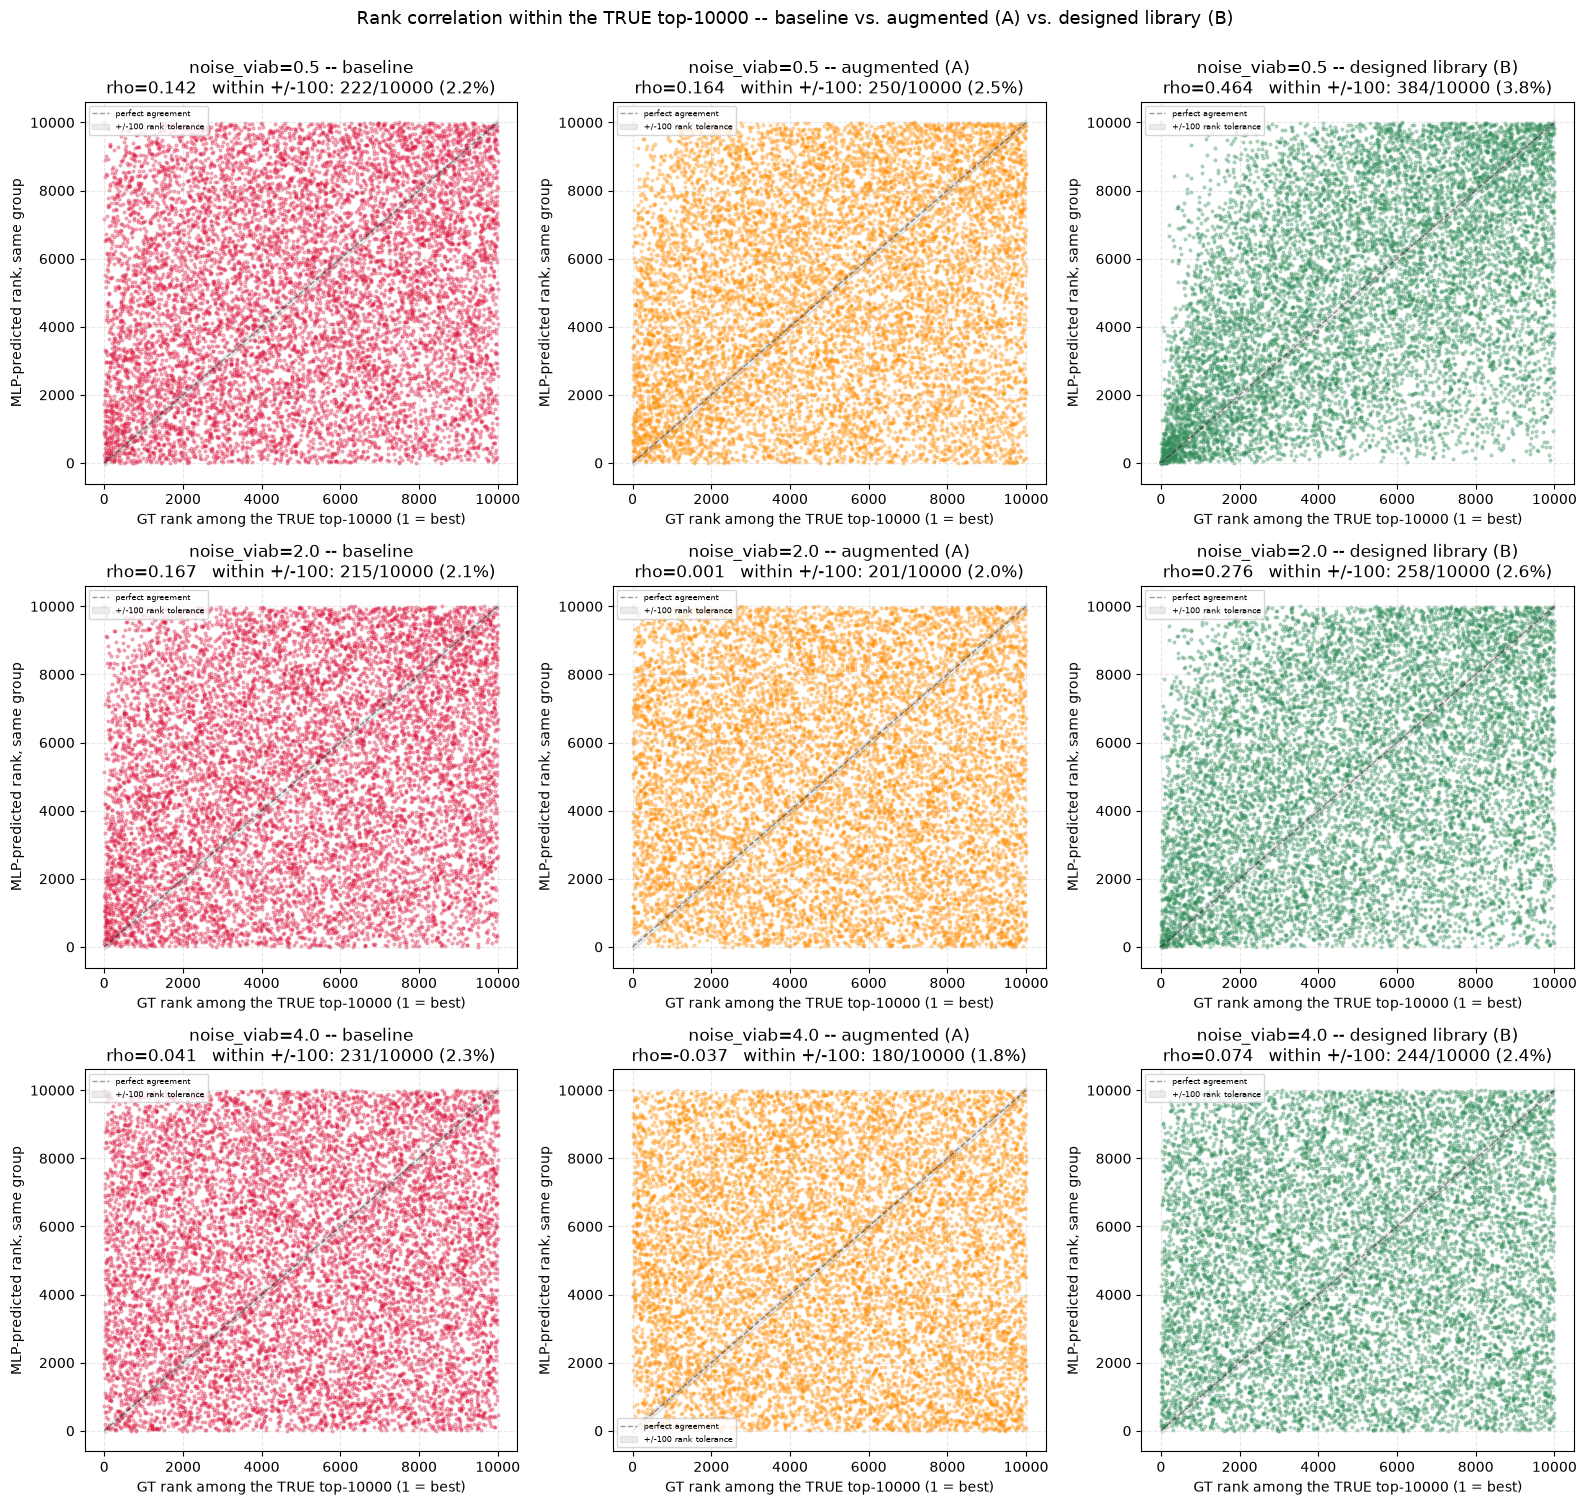

In [32]:
fig, axes = plt.subplots(len(NOISE_LEVELS_FOCUS), 3, figsize=(16, 5 * len(NOISE_LEVELS_FOCUS)))
for row, nv in enumerate(NOISE_LEVELS_FOCUS):
    panels = [
        (axes[row, 0], pred_best_baseline[nv],   "baseline",             "crimson"),
        (axes[row, 1], pred_best_A_by_noise[nv], "augmented (A)",        "darkorange"),
        (axes[row, 2], pred_best_B_by_noise[nv], "designed library (B)", "seagreen"),
    ]
    for ax, pred_best, name, color in panels:
        y_rank = mlp_rank(pred_best, ascending=False)
        rho = spearmanr(gt_rank, y_rank).statistic
        n_within, f_within = rank_agreement(pred_best, ascending=False)

        ax.scatter(gt_rank, y_rank, s=4, alpha=0.3, color=color)
        ax.plot([1, K_BEST], [1, K_BEST], "k--", alpha=0.4, lw=1, label="perfect agreement")
        ax.fill_between([1, K_BEST], [1 - RANK_TOL, K_BEST - RANK_TOL], [1 + RANK_TOL, K_BEST + RANK_TOL],
                         color="gray", alpha=0.15, label=f"+/-{RANK_TOL} rank tolerance")
        ax.set_xlabel(f"GT rank among the TRUE top-{K_BEST} (1 = best)")
        ax.set_ylabel("MLP-predicted rank, same group")
        ax.set_title(f"noise_viab={nv} -- {name}\n"
                      f"rho={rho:.3f}   within +/-{RANK_TOL}: {n_within}/{K_BEST} ({f_within:.1%})")
        ax.legend(fontsize=6)
        ax.grid(True, linestyle="--", alpha=0.3)
fig.suptitle(f"Rank correlation within the TRUE top-{K_BEST} -- baseline vs. augmented (A) vs. designed library (B)",
             y=1.0, fontsize=13)
fig.tight_layout()
plt.show()


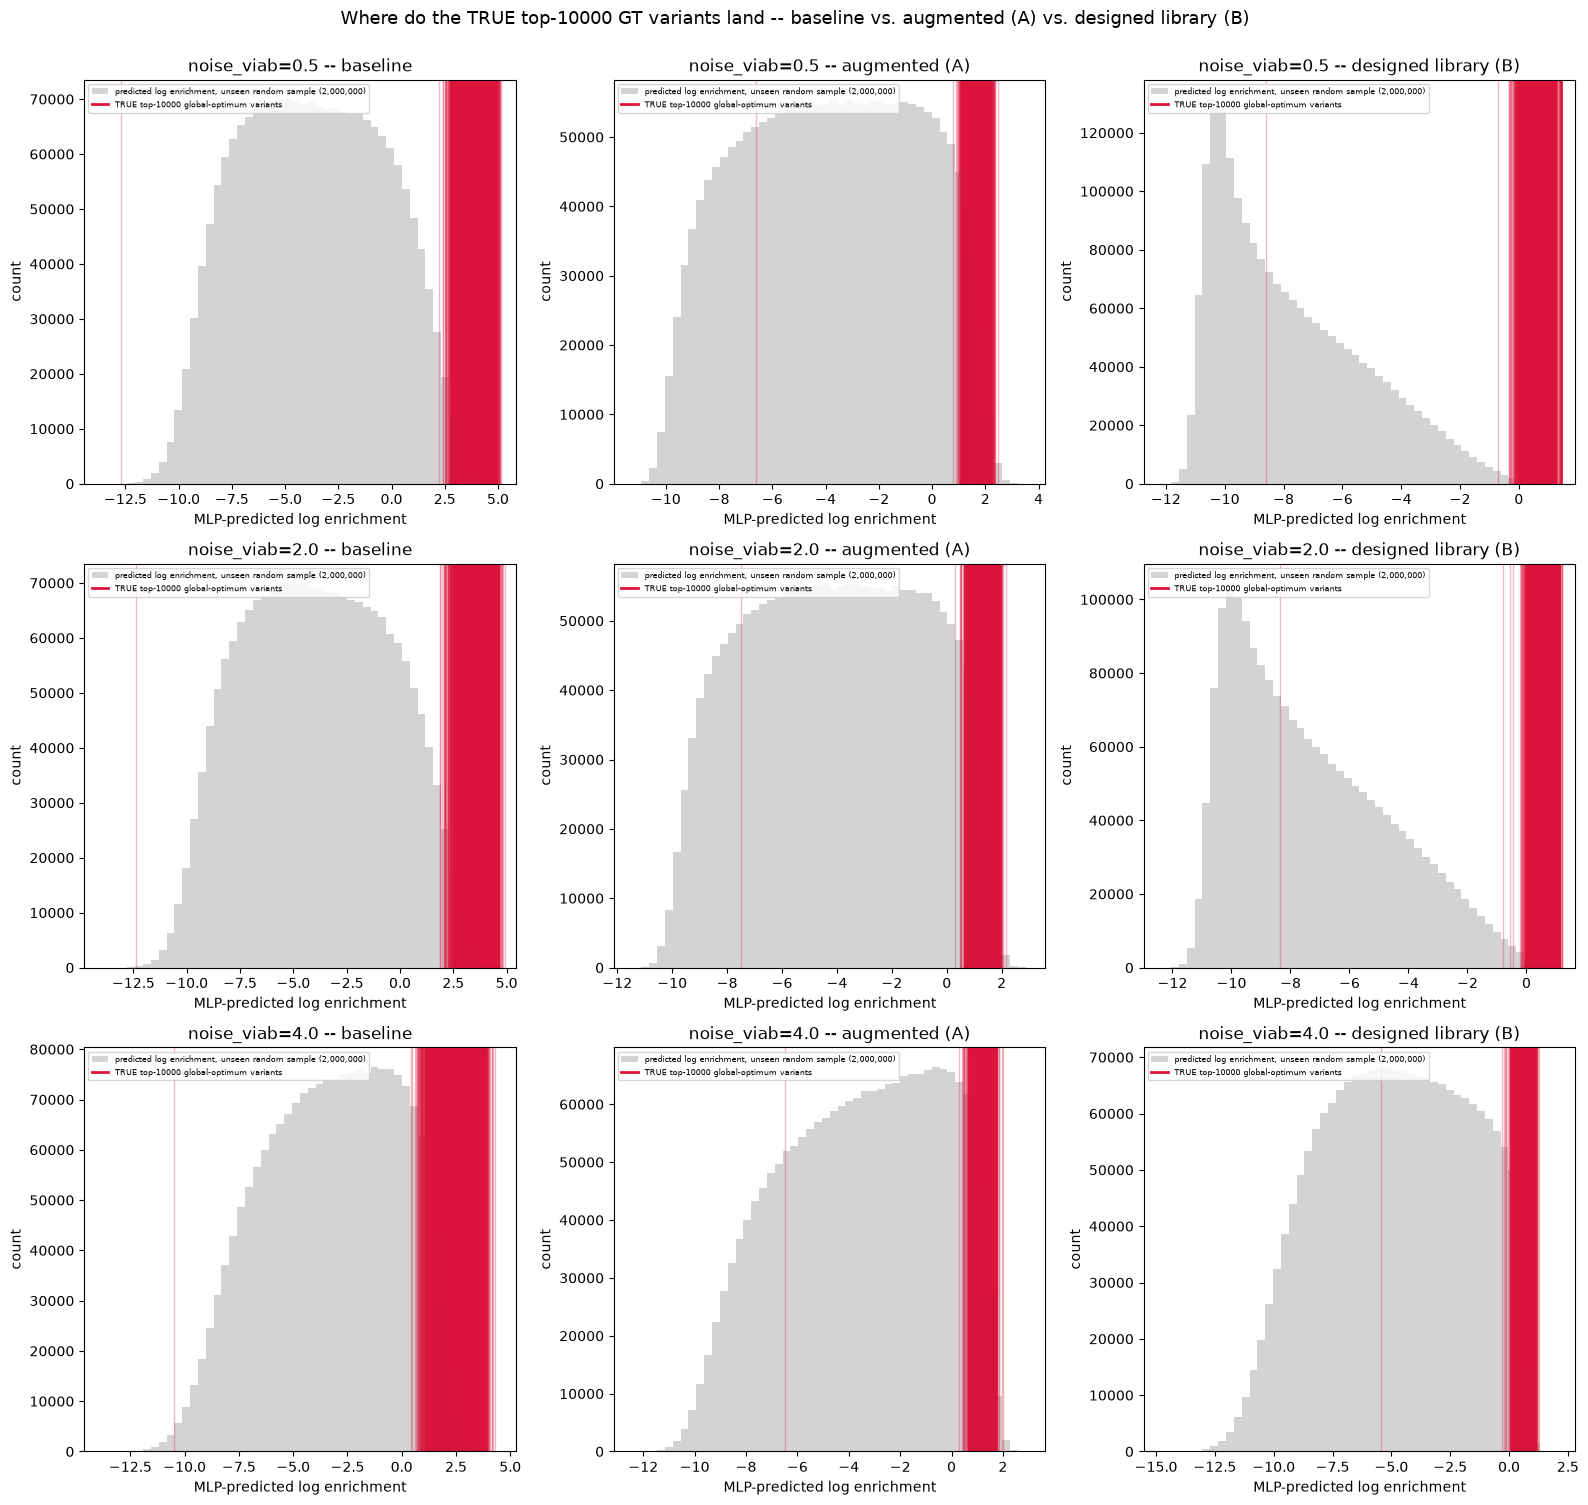

In [33]:
fig, axes = plt.subplots(len(NOISE_LEVELS_FOCUS), 3, figsize=(16, 5 * len(NOISE_LEVELS_FOCUS)))
for row, nv in enumerate(NOISE_LEVELS_FOCUS):
    panels = [
        (axes[row, 0], preds_big_by_noise[nv],   pred_best_baseline[nv],   "baseline"),
        (axes[row, 1], preds_big_A_by_noise[nv], pred_best_A_by_noise[nv], "augmented (A)"),
        (axes[row, 2], preds_big_B_by_noise[nv], pred_best_B_by_noise[nv], "designed library (B)"),
    ]
    for ax, pred_pop, pred_best, name in panels:
        ax.hist(pred_pop, bins=50, color="lightgray",
                label=f"predicted log enrichment, unseen random sample ({len(pred_pop):,})")
        for v in pred_best:
            ax.axvline(v, color="crimson", alpha=0.3, lw=1)
        ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
        ax.set_xlabel("MLP-predicted log enrichment")
        ax.set_ylabel("count")
        ax.set_title(f"noise_viab={nv} -- {name}")
        ax.legend(fontsize=6)
fig.suptitle(f"Where do the TRUE top-{K_BEST} GT variants land -- baseline vs. augmented (A) vs. designed library (B)",
             y=1.0, fontsize=13)
fig.tight_layout()
plt.show()


## How to read this

- If `r_model` (crimson, left plot of section 5) stays clearly ABOVE `r_raw` (gray) as `noise_viab`
  grows, the MLP is genuinely denoising -- averaging over the training pool's redundancy to recover
  a signal cleaner than any single noisy measurement.
- If `r_model` tracks `r_raw` closely and both collapse together, the model is just memorizing/
  mirroring whatever noisy label it was handed, with no real denoising benefit -- at that point more
  `noise_viab` simply destroys the learnable signal, full stop.
- The section-6 scatter plots make the same point visually: a denoising model should keep looking
  like a (noisy but centered) diagonal line as noise grows, not degenerate into a flat blob.
